# Regression by Minimizing Absolute Deviation — Experimental Workflow

This notebook contains the empirical OLS/LAD comparison, error-distribution experiment, runtime benchmark, implementation validation, and retained HBK visualization.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display, Image

from absolute_deviation.data import DATASETS, load_dataset
from absolute_deviation.experiments import (
    FIGURE_DIR,
    RESULT_DIR,
    run_original_data,
    run_error_distribution_experiment,
    run_runtime_benchmark,
    validate_lad_solver,
)
from absolute_deviation.plotting import generate_all_figures


## 1. Data preparation


In [2]:
dataset_rows = []
for name in DATASETS:
    X, y, predictors = load_dataset(name)
    dataset_rows.append({
        'dataset': name,
        'observations': len(y),
        'predictors': X.shape[1],
        'predictor_names': ', '.join(predictors),
    })
display(pd.DataFrame(dataset_rows))


,dataset,observations,predictors,predictor_names
0,boston_housing,506,12,"CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD,..."
1,concrete_strength,1030,8,"Cement, BlastFurnaceSlag, FlyAsh, Water, Super..."
2,hbk,75,3,"X1, X2, X3"


## 2. Fit OLS and LAD on the empirical datasets


In [3]:
metrics_df, coefficients_df = run_original_data()
display(metrics_df[['dataset', 'model', 'SSE', 'SAE']])


,dataset,model,SSE,SAE
0,boston_housing,OLS,11349.418808,1698.290859
1,boston_housing,LAD,12469.793173,1611.011000
2,concrete_strength,OLS,110428.156817,8461.346375
3,concrete_strength,LAD,119464.579642,8289.485903
4,hbk,OLS,359.485726,103.468960
5,hbk,LAD,587.732546,86.742870


## 3. HBK multivariate residual visualization


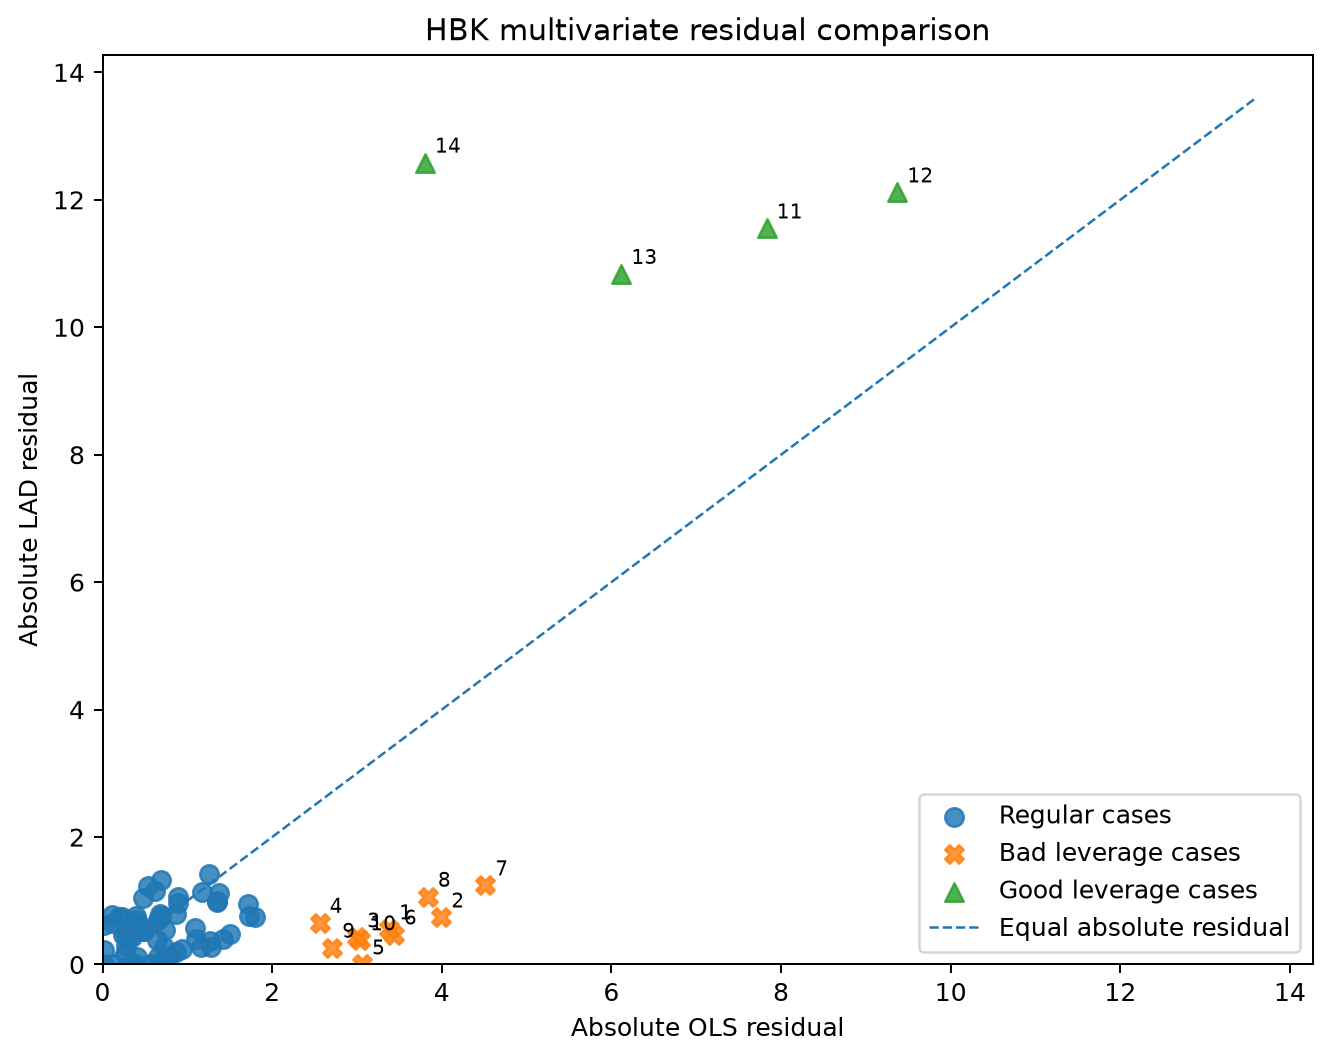

In [4]:
generate_all_figures()
display(Image(filename=str(FIGURE_DIR / 'hbk_multivariate_inlier_outlier.png')))


## 4. Error-distribution experiment


In [5]:
distribution_df = run_error_distribution_experiment()
distribution_summary = (
    distribution_df.groupby(['distribution', 'model'])[['SSE', 'SAE']]
    .median()
    .reset_index()
)
display(distribution_summary)


,distribution,model,SSE,SAE
0,cauchy,LAD,35609.348491,618.839994
1,cauchy,OLS,34963.599789,728.415940
2,laplace,LAD,144.070318,103.539847
3,laplace,OLS,141.468985,105.115256
4,normal,LAD,152.367946,117.521277
5,normal,OLS,150.067574,118.655277


## 5. Runtime benchmark


In [6]:
runtime_df = run_runtime_benchmark()
runtime_summary = (
    runtime_df.groupby(['n', 'p', 'model'])['runtime_seconds']
    .median()
    .reset_index()
)
display(runtime_summary)


,n,p,model,runtime_seconds
0,50,1,LAD,0.001897
1,50,1,OLS,0.000076
2,50,3,LAD,0.001970
3,50,3,OLS,0.000045
4,50,5,LAD,0.002104
5,50,5,OLS,0.000050
6,100,1,LAD,0.002776
7,100,1,OLS,0.000040
8,100,3,LAD,0.003000
9,100,3,OLS,0.000046


## 6. Implementation validation


In [7]:
validation_df = validate_lad_solver()
display(validation_df)


,example,ols_sse,lad_sse,ols_sae,lad_sae,ols_sse_is_minimum_against_lad,lad_sae_is_minimum_against_ols
0,1,3.621429e+02,676.0,4.085714e+01,26.0,True,True
1,2,9.860761e-32,0.0,4.440892e-16,0.0,True,True


## 7. Generated outputs


In [8]:
result_files = sorted(path.name for path in RESULT_DIR.glob('*'))
figure_files = sorted(path.name for path in FIGURE_DIR.glob('*'))
display(pd.DataFrame({'result_files': pd.Series(result_files)}))
display(pd.DataFrame({'figure_files': pd.Series(figure_files)}))


,result_files
0,distribution_experiment.csv
1,lad_solver_validation.csv
2,original_data_coefficients.csv
3,original_data_metrics.csv
4,runtime_results.csv


,figure_files
0,hbk_multivariate_inlier_outlier.png
